<a href="https://colab.research.google.com/github/frank20100206/YTP-demo/blob/main/3_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Computer Vision

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'numpy.ndarray'>
(562, 750, 3)
[[[235 238 236]
  [235 238 236]
  [235 238 236]
  ...
  [252 254 254]
  [252 254 254]
  [252 254 254]]

 [[235 238 236]
  [235 238 236]
  [235 238 236]
  ...
  [252 254 254]
  [252 254 254]
  [252 254 254]]

 [[235 238 236]
  [235 238 236]
  [235 238 236]
  ...
  [252 254 254]
  [252 254 254]
  [252 254 254]]

 ...

 [[  8 140 147]
  [  8 135 143]
  [  3 124 134]
  ...
  [216 219 217]
  [216 219 217]
  [216 219 217]]

 [[  3 109 140]
  [  0 105 133]
  [  0 101 128]
  ...
  [215 219 214]
  [215 219 214]
  [215 219 214]]

 [[  3 109 140]
  [  0 105 133]
  [  0 103 130]
  ...
  [215 219 214]
  [215 219 214]
  [215 219 214]]]


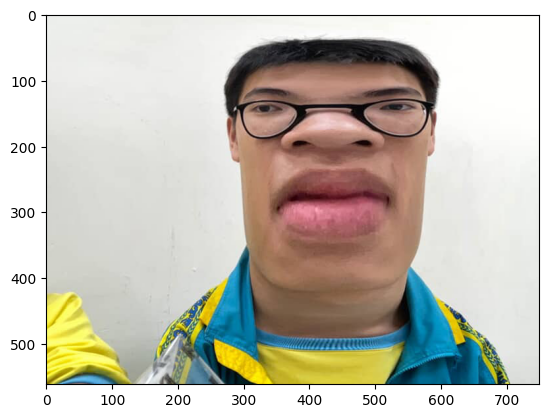

In [9]:
import cv2 # opencv
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

path = "/content/drive/MyDrive/YTP/Treeing.JPG"
image = cv2.imread(path)
print(type(image))
print(image.shape) # h, w, c
print(image)

new_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(new_image)
plt.show()

#Tensor


In [10]:
import torch

# 手動建立一個 3x2 的 2D Tensor
# 每一列 (row) 代表一個學生，每一欄 (column) 代表一個科目
grades_2d = torch.tensor([
    [85.3, 92.2],
    [70.6, 65.2],
    [99.1, 88.6]
])

print("--- 2D Tensor (3x2) ---")
print(grades_2d)
print(f"維度 (ndimension): {grades_2d.ndimension()}") # 會顯示 2
print(f"形狀 (shape): {grades_2d.shape}")             # 會顯示 [3, 2]

--- 2D Tensor (3x2) ---
tensor([[85.3000, 92.2000],
        [70.6000, 65.2000],
        [99.1000, 88.6000]])
維度 (ndimension): 2
形狀 (shape): torch.Size([3, 2])


In [11]:
# 手動建立一個 2x3x2 的 3D Tensor
# 結構：[班級數, 學生數, 科目數]
school_3d = torch.tensor([
    [ # 第一班
        [85.0, 92.0],
        [70.0, 65.0],
        [99.0, 88.0]
    ],
    [ # 第二班
        [60.0, 72.0],
        [88.0, 81.0],
        [75.0, 90.0]
    ]
])

print("\n--- 3D Tensor (2x3x2) ---")
print(school_3d)
print(f"維度 (ndimension): {school_3d.ndimension()}") # 會顯示 3
print(f"形狀 (shape): {school_3d.shape}")             # torch.Size([2, 3, 2])


--- 3D Tensor (2x3x2) ---
tensor([[[85., 92.],
         [70., 65.],
         [99., 88.]],

        [[60., 72.],
         [88., 81.],
         [75., 90.]]])
維度 (ndimension): 3
形狀 (shape): torch.Size([2, 3, 2])


#GPU

In [4]:
import torch
# 檢查是否有 GPU (CUDA)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"目前使用的設備是: {device}")

# 建立一個 Tensor 預設是在 CPU 上
x = torch.ones(3, 3)

# 移動到 GPU
x_gpu = x.to(device)

print(f"x 的位置: {x.device}")
print(f"x_gpu 的位置: {x_gpu.device}")

目前使用的設備是: cuda
x 的位置: cpu
x_gpu 的位置: cuda:0


#Autograd

In [5]:
import torch

# 建立一個張量並開啟梯度追蹤
x = torch.tensor(3.0, requires_grad=True)

# 定義一個函數 y = 3x^2 + 4x + 5
y = 3*x**2 + 4*x + 5

print(f"x 的值: {x}")
print(f"y 的計算結果: {y}") # y = 3(9) + 4(3) + 5 = 44

x 的值: 3.0
y 的計算結果: 44.0


In [6]:
# 呼叫 backward() 開始自動微分
y.backward()

# 查看 x 的梯度 (Gradient)
print(f"PyTorch 算出的梯度 (dy/dx): {x.grad}")

PyTorch 算出的梯度 (dy/dx): 22.0


In [7]:
print(f"x 是否在追蹤梯度? {x.requires_grad}")

# 使用 torch.no_grad() 包起來
with torch.no_grad():
    z = x * 2
    print(f"z 的 requires_grad 狀態: {z.requires_grad}")

x 是否在追蹤梯度? True
z 的 requires_grad 狀態: False


In [8]:
# 模擬兩次運算
for i in range(2):
    y = x**2
    y.backward()
    print(f"第 {i+1} 次運算後的 x.grad: {x.grad}")

    # 如果不手動歸零，第二次會變 6 + 6 = 12
    # 在訓練模型時，我們必須執行：
    # x.grad.zero_()

第 1 次運算後的 x.grad: 28.0
第 2 次運算後的 x.grad: 34.0
